In [5]:
# Import the custom analysis module with forced reload
import importlib
import sys

# Remove from cache if it exists and force reload
if 'lp_analysis' in sys.modules:
    del sys.modules['lp_analysis']

# Fresh import
from lp_analysis import (
    AssetPair, PriceRange, LPConfig,
    LPCalculator, LPAnalyzer, LPVisualizer
)

from lp_analysis import (
    AssetPair, PriceRange, LeveragedLPConfig, DebtAsset,
    LeveragedLPCalculator, LPAnalyzer, RiskAnalyzer, LPVisualizer
)

print(" Module reloaded with breakeven line functionality!")

 Module reloaded with breakeven line functionality!


Initial Position:
  ETH: 0.980194
  USDC: 5099.03
  Liquidity: 3569.13
Max Gain: $97.06
Max Loss: $-905.37


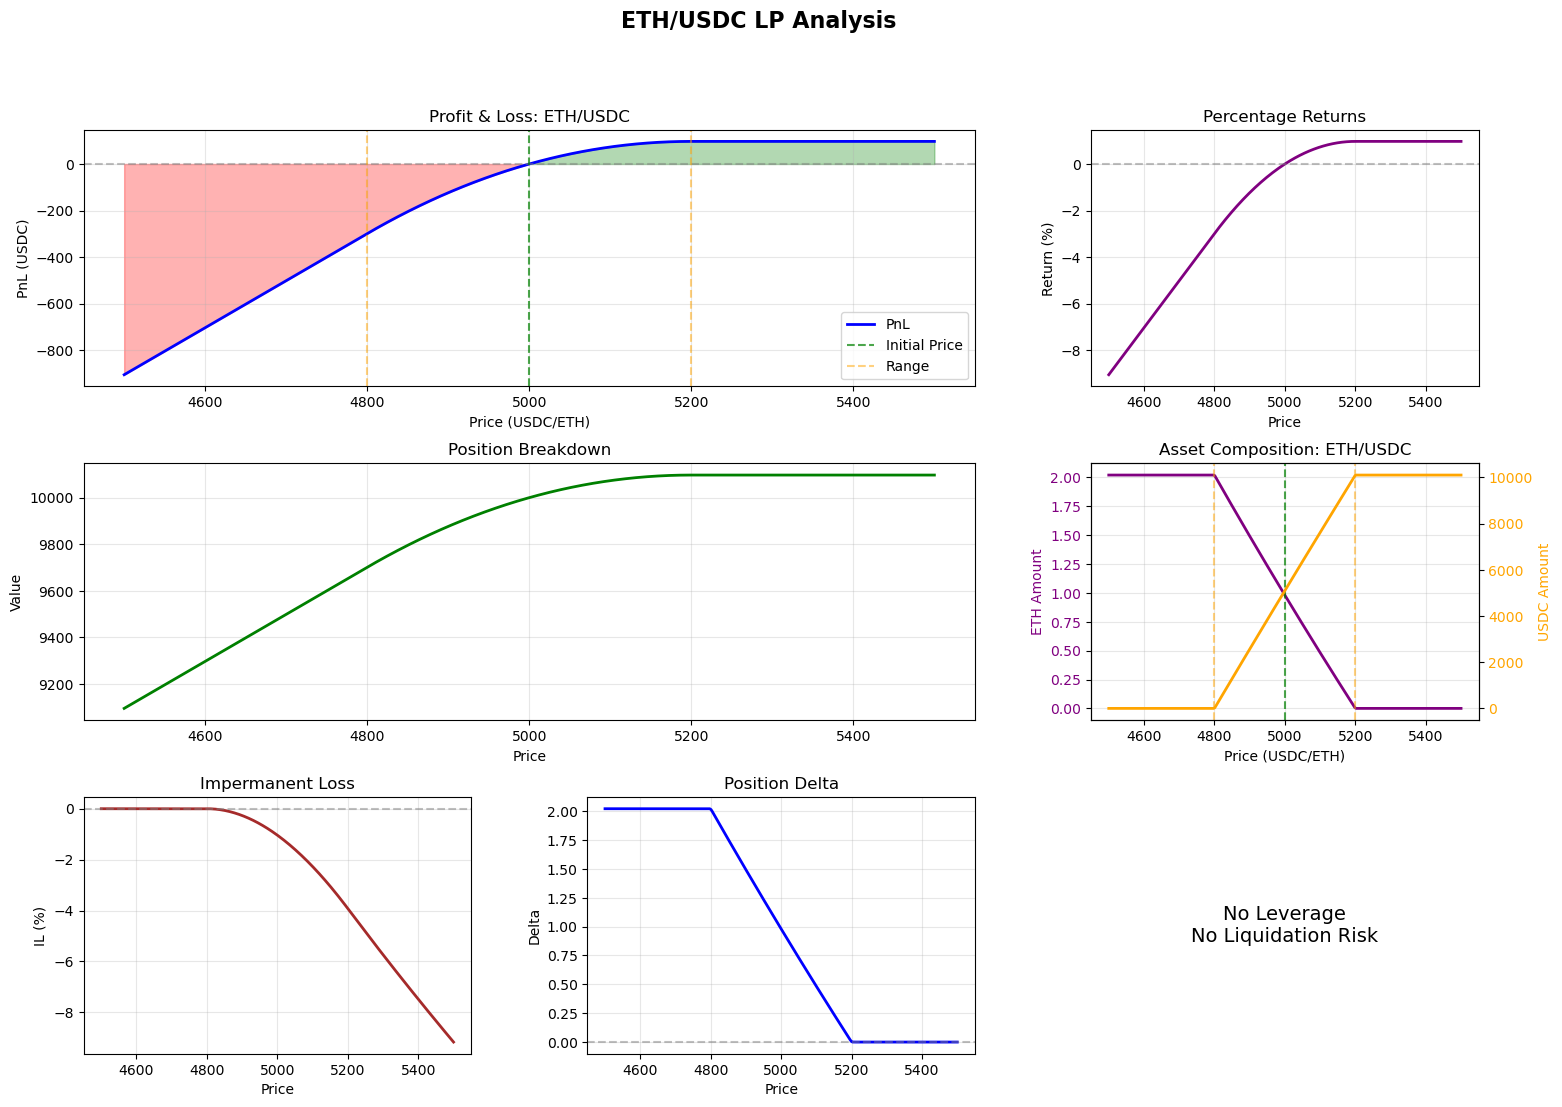

In [6]:

# Cell 2: Configure LP
config = LPConfig(
    capital_asset1=10000,  # $10k USDC
    price_initial=5000,    # $5000/ETH
    price_range=PriceRange(4800, 5200),
    assets=AssetPair("ETH", "USDC"),
    fee_tier=0.3
)

# Cell 3: Calculate
calc = LPCalculator()
initial_pos = calc.calculate_initial_position(config)

print(f"Initial Position:")
print(f"  ETH: {initial_pos.amount0:.6f}")
print(f"  USDC: {initial_pos.amount1:.2f}")
print(f"  Liquidity: {initial_pos.liquidity:.2f}")

# Cell 4: Simulate

result = LeveragedLPCalculator().simulate_price_range(
    config, price_min=4500, price_max=5500
)

# Cell 5: Analyze
result = LPAnalyzer.analyze_simulation(result)

print(f"Max Gain: ${result.metrics['pnl']['max_gain']:.2f}")
print(f"Max Loss: ${result.metrics['pnl']['max_loss']:.2f}")

# Cell 6: Visualize
LPVisualizer.plot_comprehensive_dashboard(result)

/Users/mesfahani1/myProjects/project_defi_analyzer/lp_analysis/lp_calc/types.py:86: UserWarning: Requested leverage 6.0x exceeds protocol max 1.80x (LTV=0.8)
  warnings.warn(


Leveraged LP: ETH/USDC @ 6.0x
Liquidation Range: No liquidation in simulated range
Daily Cost: $4.38
VaR (95%): $-3594.10


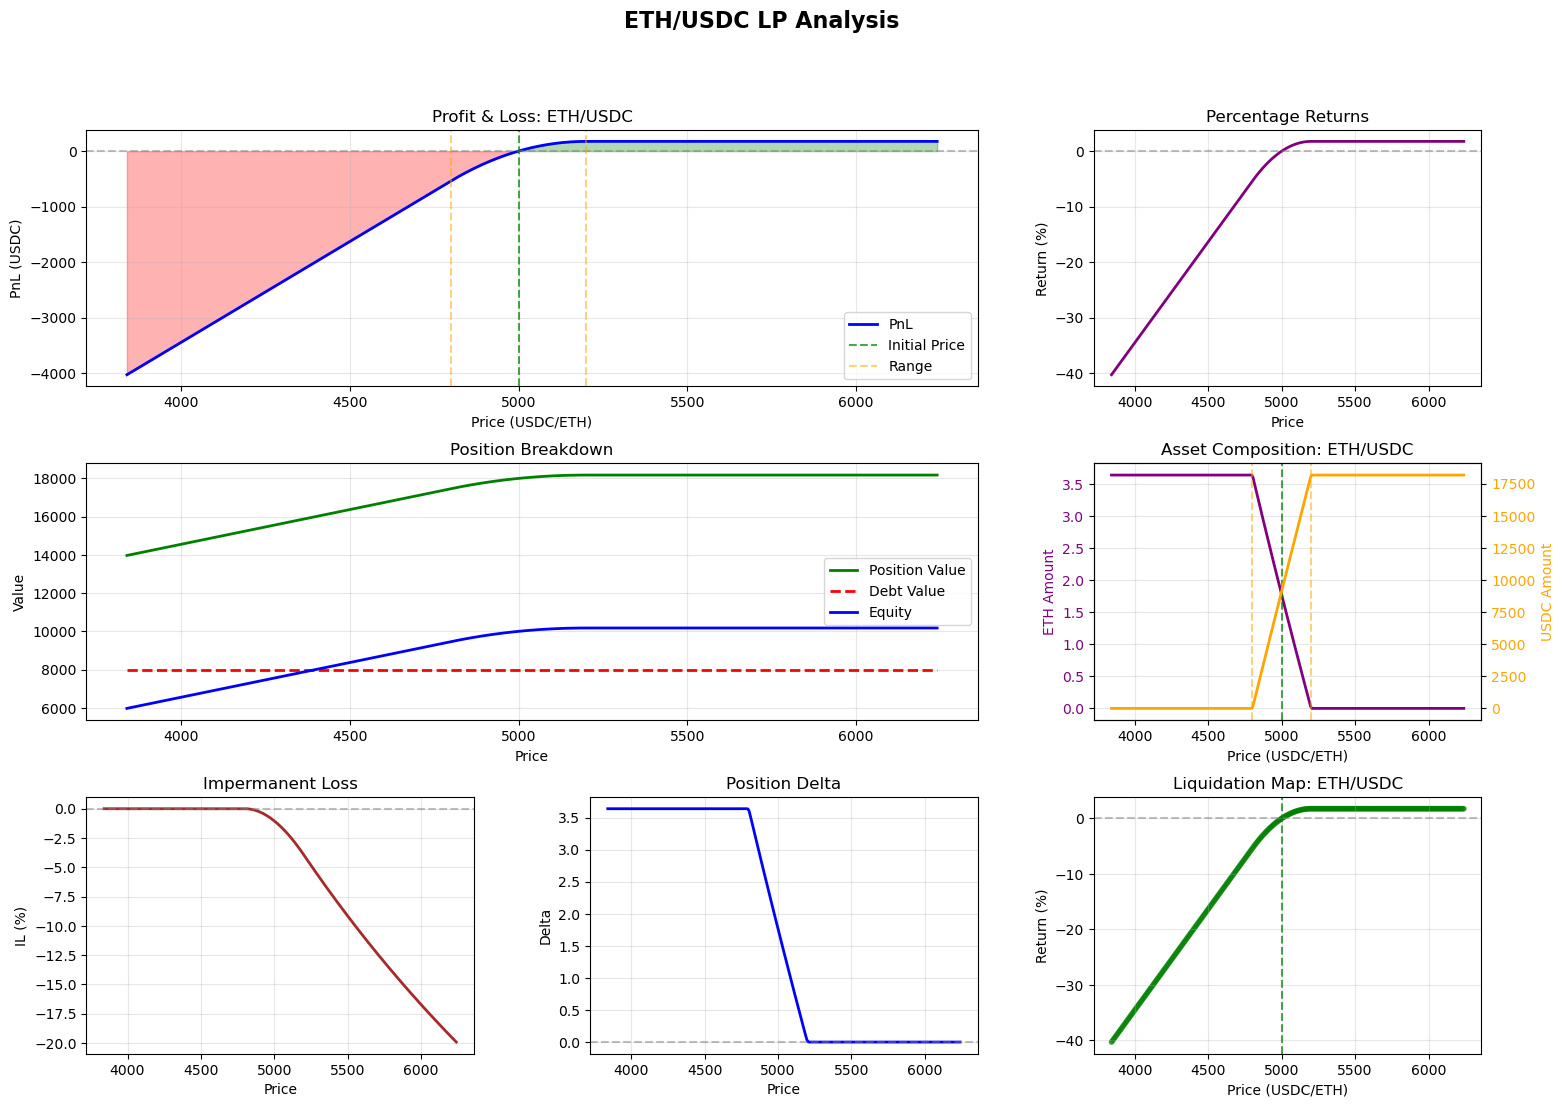

In [8]:

# Cell 2: Configure Leveraged LP
config = LeveragedLPConfig(
    capital_asset1=10000,
    price_initial=5000,
    price_range=PriceRange(4800, 5200),
    assets=AssetPair("ETH", "USDC"),
    leverage=6.0,
    debt_asset=DebtAsset.ASSET1,  # Borrow USDC
    borrow_apr=20.0,
    max_ltv=0.8,
    liquidation_threshold=0.85
)

# Cell 3: Simulate
calc = LeveragedLPCalculator()
result = calc.simulate_price_range(config)

# Cell 4: Analyze
result = LPAnalyzer.analyze_simulation(result)
result.metrics['risk'] = RiskAnalyzer.analyze_risk(result)

# Cell 5: Print Summary
liq = result.metrics['risk']['liquidation_prices']
print(f"Leveraged LP: {config.assets} @ {config.leverage}x")
if liq['lower'] is not None:
    print(f"Liquidation Range: [{liq['lower']:.2f}, {liq['upper']:.2f}]")
else:
    print(f"Liquidation Range: No liquidation in simulated range")
print(f"Daily Cost: ${result.metrics['risk']['daily_cost']:.2f}")
if result.metrics['risk']['var_95'] is not None:
    print(f"VaR (95%): ${result.metrics['risk']['var_95']:.2f}")

# Cell 6: Visualize
LPVisualizer.plot_comprehensive_dashboard(result)
